In [19]:
import sys
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import pickle
import torch as pt
import os
import PcmPy as pcm
import HierarchBayesParcel.full_model as fm
import HierarchBayesParcel.util as ut
import HierarchBayesParcel.emissions as em
import HierarchBayesParcel.evaluation as ev
from OptimalBattery.util import eigenval_crit,build_combinations, combination_vectors
from DCBC.utilities import compute_dist
import nitools as nt
from IndividualParcellation.evaluate import calc_test_dcbc


In [20]:
# pytorch cuda global flag: True - cuda; False - cpu
if pt.cuda.is_available():
    DEVICE = 'cuda'
else:
    DEVICE = 'cpu'
pt.set_default_device(DEVICE)
pt.set_default_dtype(pt.float32)

print('DEVICE:', DEVICE)

DEVICE: cuda


In [39]:
# load data and info from pickle
with open('C:/Users/barafat/Documents/data_mdtb_s1_SUIT3.pkl', 'rb') as f:
    data_mdtb_s1 = pickle.load(f)



#load info
with open('C:/Users/barafat/Documents/info_mdtb_1.pkl', 'rb') as f:
    info = pickle.load(f)

In [40]:
base_conditions = ['ToM', 'VerbGen', 'VideoAct', 'FingerSeq', 'FingerSimple', 'WordRead']

condition_mask = info['cond_name'].str.extract(f"({'|'.join(base_conditions)})", expand=False).notna()

target_indices = condition_mask[condition_mask].index.to_numpy()

data_mdtb_s1 = data_mdtb_s1[:, target_indices, :]
info = info.loc[target_indices].reset_index(drop=True)


In [41]:

# Define data dimensions
n_subjects, n_conditions_x_runs, n_voxels = data_mdtb_s1.shape

# Get unique condition names and repetitions per condition
condition_names = info['cond_name'].unique()
n_conditions = len(condition_names)

# Initialize new data array and an empty list for the new metadata
new_data = np.zeros((n_subjects, n_conditions_x_runs, n_voxels))
new_info_list = []

# Define the number of runs per condition (assuming evenly split across 4 runs)
runs_per_condition = 4  # Adjust as needed if different in your data

# Track the overall index in new_data for each run
current_index = 0

# Step 1: Loop over the runs instead of conditions, to interleave runs correctly
for run_number in range(runs_per_condition):
    # Step 2: Iterate through conditions to pick the right repetitions for each run
    for condition_idx, cond_name in enumerate(condition_names):
        # Extract all indices for the current condition and select the current run
        condition_indices = info[info['cond_name'] == cond_name].index
        # Calculate the range of repetitions for this run (e.g., 4 repetitions per run)
        start_idx = run_number * 4
        end_idx = (run_number + 1) * 4

        # Place these repetitions in the new data matrix at the correct index position
        new_data[:, current_index:current_index + 4, :] = data_mdtb_s1[:, condition_indices[start_idx:end_idx], :]

        # Create new condition names and update the metadata accordingly
        new_condition_name = f"{cond_name}{run_number + 1}"
        for rep_idx in range(4):
            new_condition_name = f"{cond_name}{rep_idx + 1}"
            new_info_list.append({
                'cond_name': new_condition_name,
                'run': run_number + 1,
                'task_name': info.loc[condition_indices[start_idx], 'task_name'],
                'cond_num': condition_idx + 1,
                'instruction': info.loc[condition_indices[start_idx], 'instruction'],
                'cond_code': f"{new_condition_name}-run{run_number + 1}"
            })

        # Update index counter for the new data matrix
        current_index += 4

# Convert the new metadata list into a DataFrame
info_new = pd.DataFrame(new_info_list)




In [43]:
# Calculate the total variance for each (condition x repetition) combination across voxels and subjects
total_variances = np.var(new_data, axis=(0, 2))

# Compute the target variance as the mean of these variances
target_variance = total_variances.mean()

# Calculate the scaling factors
scaling_factors = np.sqrt(target_variance / total_variances)

# Apply scaling to each condition x repetition in a single operation
new_data_scaled = new_data * scaling_factors[np.newaxis, :, np.newaxis]




In [45]:
print(f"Total variance (Condition 2): {np.sum(np.var(new_data_scaled[:, 2, :]))}")
print(f"Total variance (Condition 3): {np.sum(np.var(new_data_scaled[:, 3, :]))}")


Total variance (Condition 2): 0.0271695195722249
Total variance (Condition 3): 0.027169519572224913


In [46]:
subject_condition_variances = np.var(new_data, axis=2) 

target_variances_per_subject = subject_condition_variances.mean(axis=1, keepdims=True)  # shape: (n_subjects, 1)

scaling_factors_per_subject = np.sqrt(target_variances_per_subject / subject_condition_variances)  # shape: (n_subjects, n_conditions_x_runs)

new_data_scaled_subject = new_data * scaling_factors_per_subject[:, :, np.newaxis]

variance_subject0_cond2 = np.var(new_data_scaled_subject[0, 2, :])  # Variance across voxels for Subject 0, Condition 2
variance_subject0_cond3 = np.var(new_data_scaled_subject[0, 3, :])  # Variance across voxels for Subject 0, Condition 3





Target variance for Subject 0: 0.02137373097857992
Total variance (Subject 0, Condition 2 across voxels): 0.021373730978579922
Total variance (Subject 0, Condition 3 across voxels): 0.02137373097857992


In [51]:
new_data = new_data_scaled_subject

# get cov matrix

In [47]:
unique_conditions = info_new['cond_name'][:24]
n_unique_conditions = len(unique_conditions)


averaged_data = np.zeros((n_subjects, n_unique_conditions, n_voxels))

averaged_info_list = []

for cond_idx, unique_cond in enumerate(unique_conditions):
    # Step 4.1: Get indices of all repetitions for the current condition
    rep_indices = info_new[info_new['cond_name'].str.startswith(unique_cond)].index.to_numpy()
    
    # Step 4.2: Average the data across the repetition indices
    averaged_data[:, cond_idx, :] = new_data_scaled_subject[:, rep_indices, :].mean(axis=1)
    



In [48]:
averaged_data.shape

(24, 24, 6918)

<Axes: >

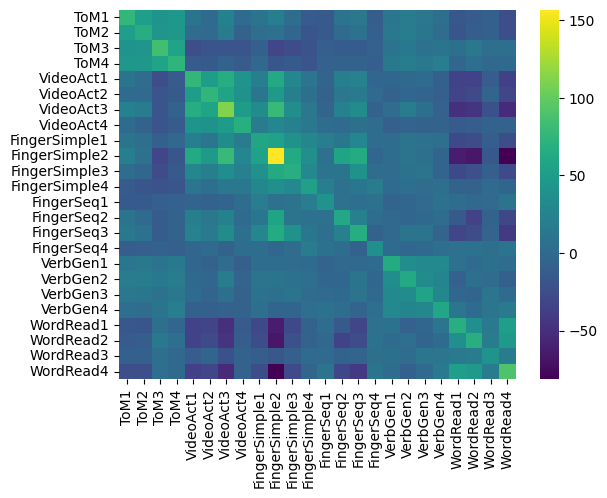

In [49]:
cov_list = []
for i in range(n_subjects):
    cov_sub = averaged_data[i] @ averaged_data[i].T
    cov_list.append(cov_sub)
#stack covariances
cov_stack = np.stack(cov_list, axis=0)
#average covariances
cov_avg = cov_stack.mean(axis=0)

sns.heatmap(cov_list[0], cmap='viridis',xticklabels= unique_conditions, yticklabels= unique_conditions)

# get the G matrix

In [74]:
# n_conds = len(np.unique(info['cond_name']))
# n_runs = len(np.unique(info['run']))
# cond_names = np.unique(info['cond_name'])

# cond_vec = np.tile(np.arange(1, n_conds + 1), n_runs)
# part_vec = np.repeat(np.arange(1, n_runs + 1), n_conds)


In [52]:
n_conds = len(np.unique(info_new['cond_name']))
n_runs = len(np.unique(info_new['run']))
cond_names = info_new['cond_name'][:24]

cond_vec = np.tile(np.arange(1, n_conds + 1), n_runs)
part_vec = np.repeat(np.arange(1, n_runs + 1), n_conds)

In [53]:
Gs_list = []
for i in range(new_data.shape[0]):
    Gs,E = pcm.util.est_G_crossval(new_data[i], cond_vec, part_vec)
    Gs_list.append(Gs)

Gs_list = np.stack(Gs_list, 0)
G_individuals_averaged = np.mean(Gs_list, axis=0)


<Axes: >

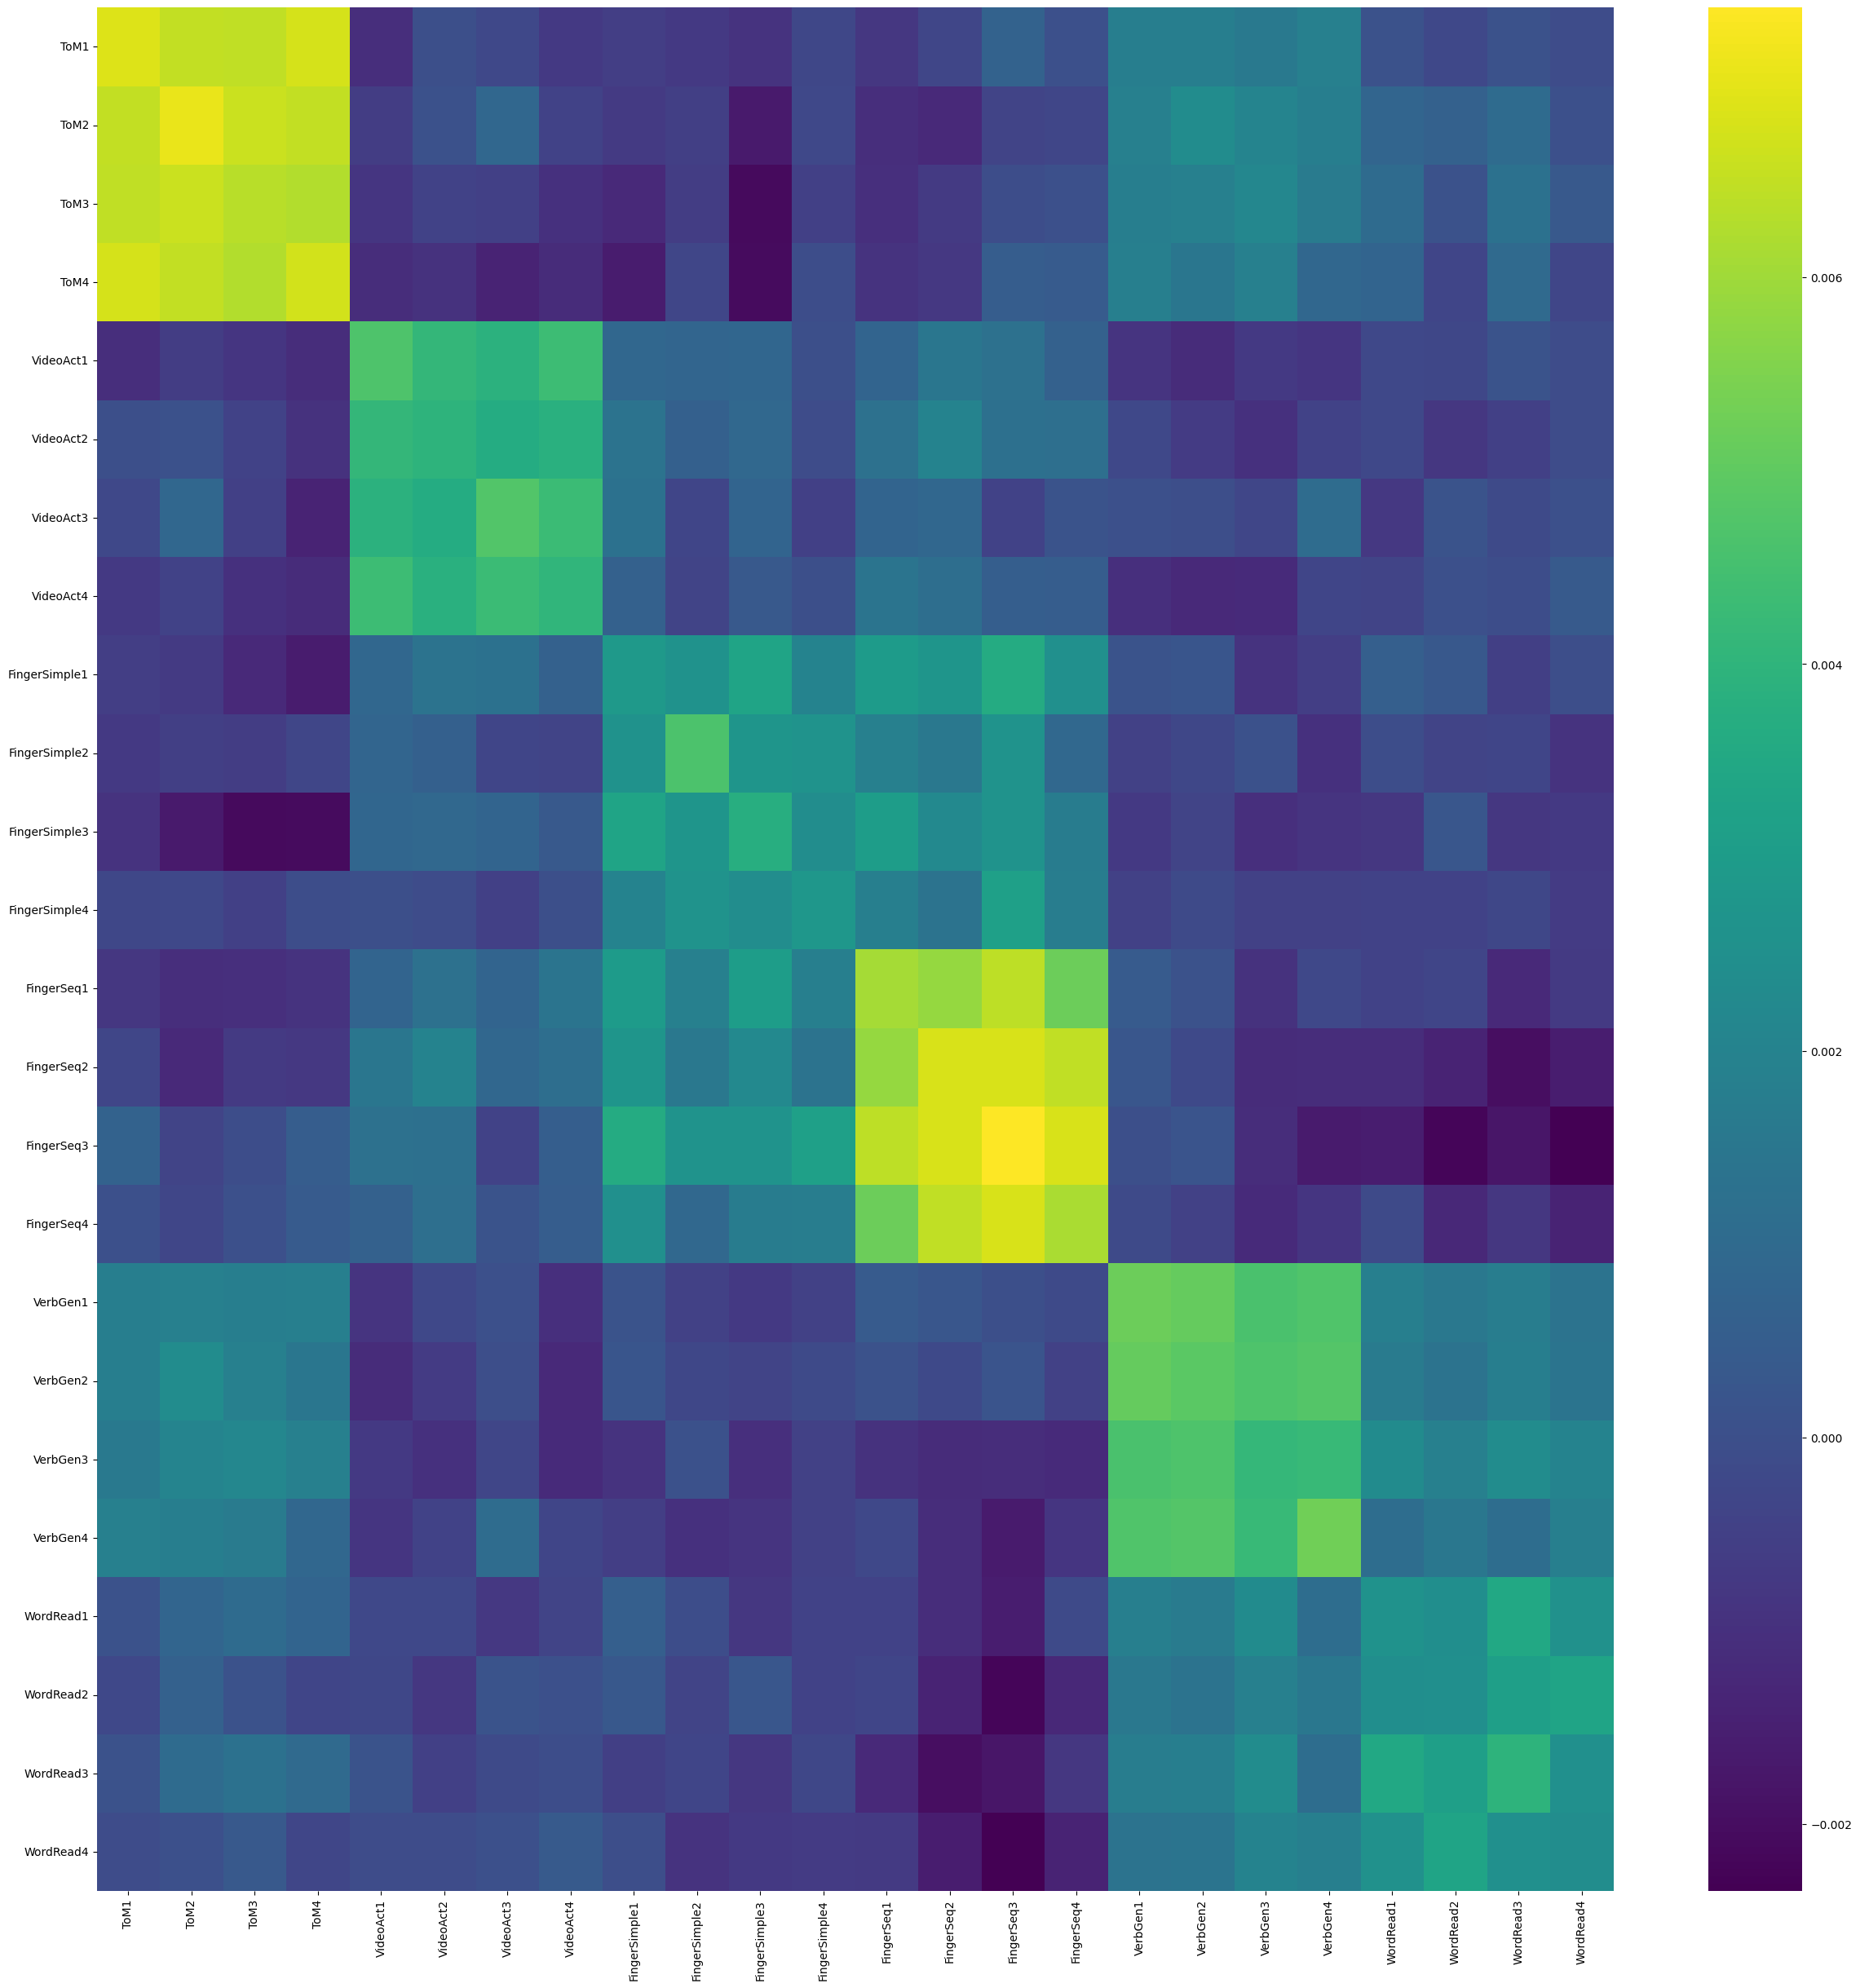

In [54]:
plt.figure(figsize=(30, 30))
sns.heatmap(G_individuals_averaged,xticklabels=cond_names, yticklabels=cond_names, cmap='viridis')

# Build combinations

In [55]:
D = build_combinations(G_individuals_averaged, strategy='random',n_iter=100,n_tasks=8)

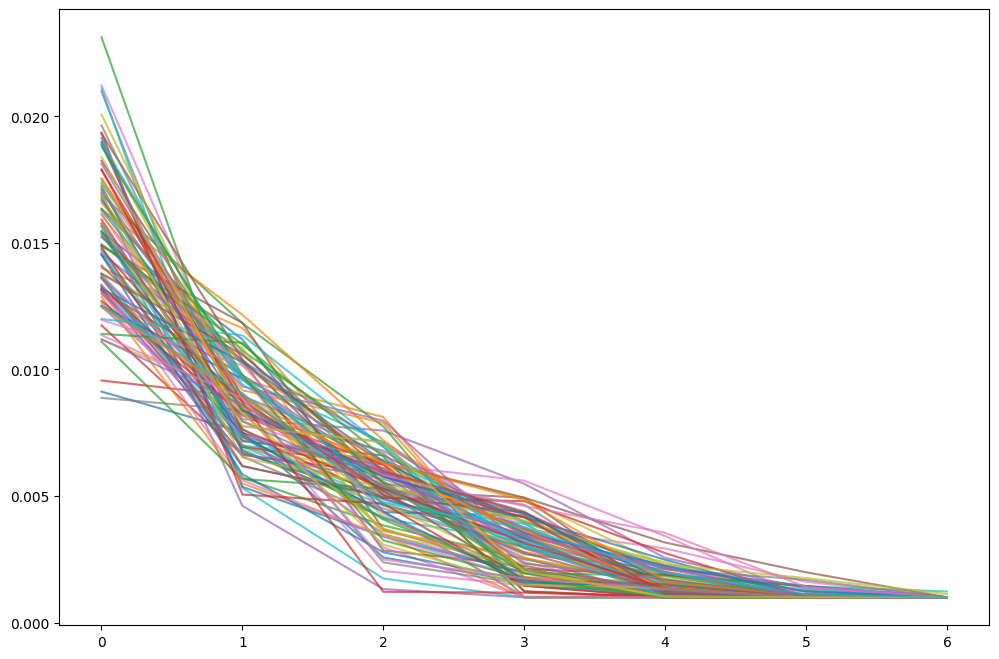

In [56]:
chosen_offset = 1e-3
filtered_D = D[D['offset'] == chosen_offset]

# Step 2: Extract eigenvalues for each combination
# Each row in `filtered_D['eigenvalues']` is a list of eigenvalues
eigenvalue_lists = filtered_D['eigenvalues'].values

# Step 3: Plot the eigenvalue spectra
plt.figure(figsize=(12, 8))  # Set up the figure size
for idx, eigenvalues in enumerate(eigenvalue_lists):
    # Plot each combination's eigenvalue spectrum
    plt.plot(eigenvalues, label=f'Combination {idx + 1}', alpha=0.7)




# Perform DCBC on combinations

In [57]:
#load model
with open('C:/Users/barafat/Documents/model.pkl', 'rb') as f:
    model = pickle.load(f)

sym_type = 'unsym'
ar_model = model.arrange
ar_model.logpi = pt.tensor(ar_model.logpi, dtype=pt.get_default_dtype())

P = data_mdtb_s1.shape[2]
K = ar_model.K

#load dist matrix
with open('C:/Users/barafat/Documents/dist.pkl', 'rb') as f:
    dist = pickle.load(f)

dist = dist.to(DEVICE)


# load evaluation data_mdtb_s2
with open('C:/Users/barafat/Documents/data_mdtb_s2_SUIT3.pkl', 'rb') as f:
    data_mdtb_s2 = pickle.load(f)


#check nans
np.isnan(data_mdtb_s2).sum()




c:\Users\barafat\AppData\Local\Programs\Python\Python38\lib\site-packages\torch\utils\_device.py:79: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return func(*args, **kwargs)


0

In [58]:
def perform_dcbc_combination(dt,c_v,p_v,data_eval):
    
    x_matrix = ut.indicator(c_v)
    em_model = em.MixVMF(K=K, P=dt.shape[2], X=x_matrix, part_vec=p_v,
                         subject_specific_kappa=False, parcel_specific_kappa=False, 
                         subjects_equal_weight=True)
    
    M_1 = fm.FullMultiModel(arrange=ar_model, emission=[em_model])
    M_1.initialize([dt])

    M_1, ll,_,U_individual = M_1.fit_em(iter=200, tol=0.01,
                                     fit_arrangement=False,
                                     fit_emission= True,
                                     first_evidence=False)    

    # Get the data-only parcellation
    emloglik = M_1.emissions[0].Estep()
    U_data = pt.softmax(emloglik, dim=1) # get data only parcellation
    
    if isinstance(data_eval, np.ndarray):
        data_eval = pt.tensor(data_eval, dtype=pt.get_default_dtype())
    if isinstance(U_data, np.ndarray):
        U_data = pt.tensor(U_data, dtype=pt.get_default_dtype())
    
    Pindiv = pt.argmax(U_data, dim=1) + 1
    dcbc_indiv = calc_test_dcbc(Pindiv, data_eval, dist,progress_updates= False)
    return dcbc_indiv.mean()


In [59]:
# def perform_cos_combination(data_train,cond_vec,part_vec,data_eval):

#     x_matrix = ut.indicator(cond_vec)    
#     em_model = em.MixVMF(K=K, P=data_train.shape[2], X=x_matrix, part_vec=part_vec,
#                          subject_specific_kappa=False, parcel_specific_kappa=False, 
#                          subjects_equal_weight=True)
    
#     M_1 = fm.FullMultiModel(arrange=ar_model, emission=[em_model])
#     M_1.initialize([data_train])

#     M_1, ll,_,U_individual = M_1.fit_em(iter=200, tol=0.01,
#                                      fit_arrangement=False,
#                                      fit_emission= True,
#                                      first_evidence=False)
    

#     # Get the data-only parcellation
#     emloglik = M_1.emissions[0].Estep()
#     U_data = pt.softmax(emloglik, dim=1) # get data only parcellation

#     parcellation = [U_data]
    
#     if isinstance(data_eval, np.ndarray):
#         data_eval = pt.tensor(data_eval, dtype=pt.get_default_dtype())
#     if isinstance(parcellation, np.ndarray):
#         parcellation = pt.tensor(parcellation, dtype=pt.get_default_dtype())

#     eval_num_runs = 16
#     eval_num_conds = 32

#     #create cond_vec and part_vec for evaluation data
#     cond_v_eval = np.tile(np.arange(1, eval_num_conds + 1), eval_num_runs)
#     part_v_eval = np.repeat(np.arange(1, eval_num_runs + 1), eval_num_conds)
#     #make into pt tensors
#     part_v_eval = pt.tensor(part_v_eval, dtype=pt.long)

#     x_matrix  = ut.indicator(cond_v_eval)

#     em_model = em.MixVMF(K=K, P=data_eval.shape[2], X=x_matrix, part_vec=part_v_eval,
#                             subject_specific_kappa=False, parcel_specific_kappa=False, 
#                             subjects_equal_weight=True)
    
#     M_eval = fm.FullMultiModel(arrange=ar_model, emission=[em_model])
#     M_eval.initialize([data_eval])
    
#     cosserror_individuals = calc_test_error(M_eval, data_eval, parcellation)
#     return cosserror_individuals.mean()

In [60]:
counter = 0
def evaluate_combination_dcbc(combination):
    global counter
    counter += 1
    print(f"Combination {counter}")

    data_train, cond_v_train, part_v_train = combination_vectors(new_data, info_new, combination, n_repeats=2)
    dcbc_value = perform_dcbc_combination(data_train, cond_v_train, part_v_train, data_mdtb_s2)
    dcbc_value = dcbc_value.item()
    
    return dcbc_value

# def evaluate_combination_cos(combination):
#     global counter
#     counter += 1
#     print(f"Combination {counter}")
#     data_train, cond_v_train, part_v_train = combination_vectors(data_mdtb_s1, info, combination, n_repeats=3)
#     cos_value = perform_cos_combination(data_train, cond_v_train, part_v_train, data_mdtb_s2)
#     cos_value = cos_value.item()
    
#     return cos_value

In [61]:
unique_combinations_df = D[D['offset'] == D['offset'].min()].copy()
unique_combinations_df['dcbc'] = unique_combinations_df['combination'].apply(evaluate_combination_dcbc)


Combination 1


C:\Users\barafat\Documents\GitHub\HierarchBayesParcel\HierarchBayesParcel\full_model.py:305: UserWarning: Likelihood decreased - terminating on iteration 42
  warnings.warn(f'Likelihood decreased - terminating on iteration {i}')


Combination 2
Combination 3
Combination 4
Not enough betas for task 'WordRead4' occurrence 3. Available betas: 0
Combination 5


C:\Users\barafat\Documents\GitHub\HierarchBayesParcel\HierarchBayesParcel\full_model.py:305: UserWarning: Likelihood decreased - terminating on iteration 65
  warnings.warn(f'Likelihood decreased - terminating on iteration {i}')


Combination 6


...

Combination 82


C:\Users\barafat\Documents\GitHub\HierarchBayesParcel\HierarchBayesParcel\full_model.py:305: UserWarning: Likelihood decreased - terminating on iteration 47
  warnings.warn(f'Likelihood decreased - terminating on iteration {i}')


Combination 83
Combination 84
Combination 85
Combination 86
Combination 87
Combination 88
Combination 89
Combination 90
Combination 91
Combination 92
Combination 93
Combination 94


C:\Users\barafat\Documents\GitHub\HierarchBayesParcel\HierarchBayesParcel\full_model.py:305: UserWarning: Likelihood decreased - terminating on iteration 49
  warnings.warn(f'Likelihood decreased - terminating on iteration {i}')


Combination 95
Combination 96
Combination 97
Combination 98
Combination 99
Combination 100


In [56]:
unique_combinations_df

,offset,max_var,min_est,log_det,log_det_5,off_diag,composite_90var,composite_75var,composite_50var,composite_25var,composite_10var,composite_0.01var,condition_number,effective_rank,eigenvalues,combination,has_repeats,n_unique,dcbc
0,0.000001,0.017501,2.004560e+06,-58.739329,-58.739329,0.000063,0.683534,0.569601,0.379713,0.189825,0.075892,0.007532,107560.850169,8.746940,"[0.007561850168730256, 0.0067121347893608335, ...","[5, 11, 12, 8, 9, 11, 5, 15]",1,6,0.050971
3,0.000001,0.032565,1.022337e+06,-52.623351,-52.623351,0.000255,0.724188,0.603448,0.402214,0.200980,0.080239,0.007795,116760.672459,9.508768,"[0.016761672459379724, 0.0078227460053692, 0.0...","[0, 16, 1, 12, 7, 13, 6, 18]",0,8,0.046590
6,0.000001,0.024545,2.003767e+06,-57.209840,-57.209840,0.000158,0.702543,0.585426,0.390231,0.195036,0.077919,0.007649,114593.228156,9.105044,"[0.014594228155527831, 0.004777696785560933, 0...","[20, 5, 18, 20, 11, 10, 14, 18]",1,6,0.043808
9,0.000001,0.023443,2.001901e+06,-55.767841,-55.767841,0.000050,0.699580,0.582975,0.388633,0.194292,0.077687,0.007724,108544.333574,9.179713,"[0.008545333573762904, 0.007682943561728997, 0...","[4, 23, 23, 9, 17, 23, 0, 22]",1,6,0.043530
12,0.000001,0.035045,1.028525e+06,-50.116356,-50.116356,0.000193,0.730889,0.609042,0.405964,0.202886,0.081039,0.007930,115223.155496,9.805240,"[0.015224155495703046, 0.00738930290084041, 0....","[13, 9, 9, 7, 22, 1, 0, 17]",1,7,0.046325
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
285,0.000001,0.025904,2.005662e+06,-57.898416,-57.898416,0.000160,0.706212,0.588483,0.392269,0.196054,0.078325,0.007688,113255.329481,9.176584,"[0.013256329480836597, 0.007629969627448427, 0...","[22, 1, 23, 6, 5, 11, 7, 1]",1,7,0.045812
288,0.000001,0.020617,2.006005e+06,-59.166708,-59.166708,0.000103,0.691943,0.576602,0.384367,0.192132,0.076791,0.007586,109951.606448,8.871468,"[0.00995260644814576, 0.008262299968164343, 0....","[9, 7, 5, 6, 23, 22, 10, 7]",1,7,0.044551
291,0.000001,0.027242,2.004363e+06,-57.147089,-57.147089,0.000178,0.709822,0.591488,0.394266,0.197044,0.078711,0.007711,114570.740887,9.253798,"[0.014571740886521975, 0.006641155330869859, 0...","[5, 6, 23, 4, 2, 10, 20, 0]",0,8,0.043721
294,0.000001,0.028450,2.007603e+06,-57.911699,-57.911699,0.000193,0.713084,0.594205,0.396072,0.197940,0.079060,0.007733,115613.502014,9.286526,"[0.015614502013633416, 0.006315512771312318, 0...","[16, 3, 14, 12, 21, 16, 19, 22]",1,7,0.046463


In [57]:
# unique_combinations_df = D[D['offset'] == D['offset'].min()].copy()
# unique_combinations_df['cos'] = unique_combinations_df['combination'].apply(evaluate_combination_cos)

In [58]:
D['combination'] = D['combination'].apply(tuple)
unique_combinations_df['combination'] = unique_combinations_df['combination'].apply(tuple)

# Now perform the merge operation using the tuple values
D = D.merge(
    unique_combinations_df[['combination', 'dcbc']], 
    on='combination', 
    how='left'
)

# Analyze the results

In [59]:
A = D[D['offset'] == 0.001].copy()

In [60]:


D_metrics = A.copy()


for k in range(1, 8):  # From 1st to 7th eigenvalue
    # Sum of the first `k` eigenvalues
    D_metrics[f'eigen_sum_{k}'] = D_metrics['eigenvalues'].apply(lambda x: np.sum(x[:k]))
    
    # Product of the first `k` eigenvalues
    D_metrics[f'eigen_product_{k}'] = D_metrics['eigenvalues'].apply(lambda x: np.sum(np.log(x[:k])))
    
    # Mean of the first `k` eigenvalues
    D_metrics[f'eigen_mean_{k}'] = D_metrics['eigenvalues'].apply(lambda x: np.mean(x[:k]))
    
    # Weighted sum with higher weight for earlier eigenvalues (1st has weight k, 2nd has weight k-1, etc.)
    weights = np.arange(k, 0, -1)  # [k, k-1, ..., 1]
    D_metrics[f'weighted_sum_{k}'] = D_metrics['eigenvalues'].apply(lambda x: np.sum(np.array(x[:k]) * weights))

# Step 2: Calculate correlation between `dcbc` and each of the new metrics
metrics_to_check = [f'eigen_sum_{k}' for k in range(1, 8)] + \
                   [f'eigen_product_{k}' for k in range(1, 8)] + \
                   [f'eigen_mean_{k}' for k in range(1, 8)] + \
                   [f'weighted_sum_{k}' for k in range(1, 8)]

correlation_results = D_metrics[['dcbc'] + metrics_to_check].corr()

# Display the correlation results (only show correlations with `dcbc`)
correlation_with_dcbc = correlation_results.loc['dcbc', metrics_to_check]
print("Correlation with DCBC:\n", correlation_with_dcbc)



Correlation with DCBC:
 eigen_sum_1       -0.000183
eigen_sum_2        0.038522
eigen_sum_3        0.099887
eigen_sum_4        0.156834
eigen_sum_5        0.154959
eigen_sum_6        0.151876
eigen_sum_7        0.151876
eigen_product_1   -0.003535
eigen_product_2    0.035196
eigen_product_3    0.145168
eigen_product_4    0.194512
eigen_product_5    0.154547
eigen_product_6    0.140172
eigen_product_7    0.140172
eigen_mean_1      -0.000183
eigen_mean_2       0.038522
eigen_mean_3       0.099887
eigen_mean_4       0.156834
eigen_mean_5       0.154959
eigen_mean_6       0.151876
eigen_mean_7       0.151876
weighted_sum_1    -0.000183
weighted_sum_2     0.020868
weighted_sum_3     0.052405
weighted_sum_4     0.085930
weighted_sum_5     0.104651
weighted_sum_6     0.115342
weighted_sum_7     0.122260
Name: dcbc, dtype: float64


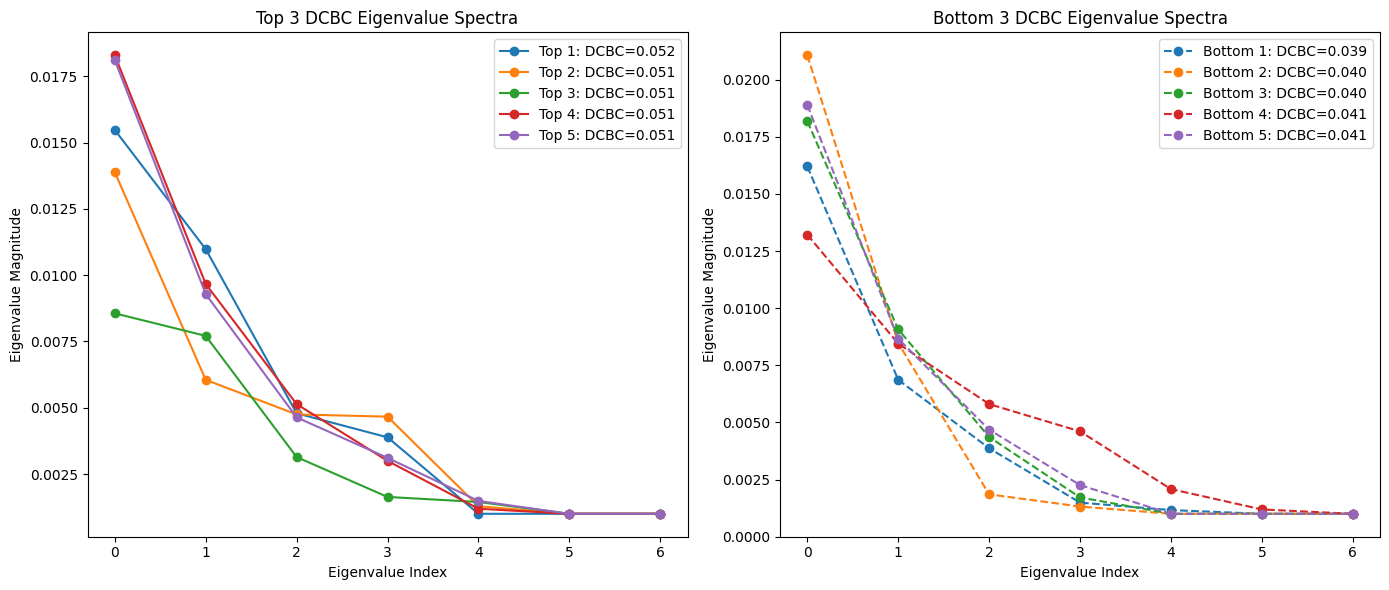

In [61]:

# Step 1: Filter the DataFrame for the desired offset
A = D[D['offset'] == 0.001].copy()

# Step 2: Sort by `dcbc` values to get top 3 and bottom 3 rows
top_3 = A.nlargest(5, 'dcbc')
bottom_3 = A.nsmallest(5, 'dcbc')

# Step 3: Extract the eigenvalues for the top and bottom rows
top_3_eigenvalues = top_3['eigenvalues'].values
bottom_3_eigenvalues = bottom_3['eigenvalues'].values

# Step 4: Plot the eigenvalue spectra
plt.figure(figsize=(14, 6))

# Plotting the top 3 eigenvalue spectra
plt.subplot(1, 2, 1)
for idx, eigenvalues in enumerate(top_3_eigenvalues, 1):
    plt.plot(eigenvalues, marker='o', label=f'Top {idx}: DCBC={top_3["dcbc"].iloc[idx - 1]:.3f}')
plt.title('Top 3 DCBC Eigenvalue Spectra')
plt.xlabel('Eigenvalue Index')
plt.ylabel('Eigenvalue Magnitude')
plt.legend()

# Plotting the bottom 3 eigenvalue spectra
plt.subplot(1, 2, 2)
for idx, eigenvalues in enumerate(bottom_3_eigenvalues, 1):
    plt.plot(eigenvalues, marker='o', linestyle='--', label=f'Bottom {idx}: DCBC={bottom_3["dcbc"].iloc[idx - 1]:.3f}')
plt.title('Bottom 3 DCBC Eigenvalue Spectra')
plt.xlabel('Eigenvalue Index')
plt.ylabel('Eigenvalue Magnitude')
plt.legend()

# Display the plots
plt.tight_layout()
plt.show()


In [62]:
# show many combinations are repeated
n_repeated = len(A[A['has_repeats'] == True])
n_unique = len(A[A['has_repeats'] == False])

n_repeated, n_unique


(76, 24)

<Axes: xlabel='dcbc', ylabel='Count'>

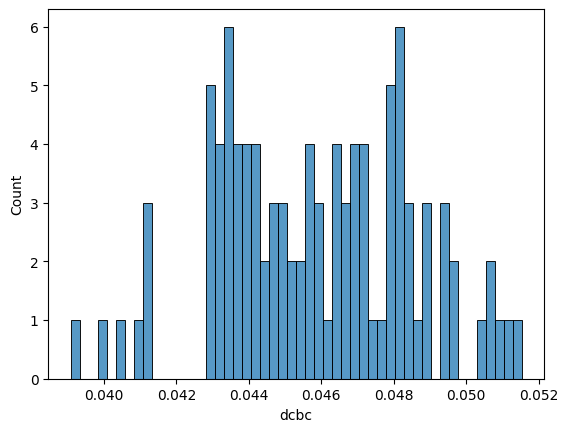

In [63]:
# plot the distribution of the DCBC values
sns.histplot(A['dcbc'], bins=50)

<Axes: xlabel='min_est', ylabel='max_var'>

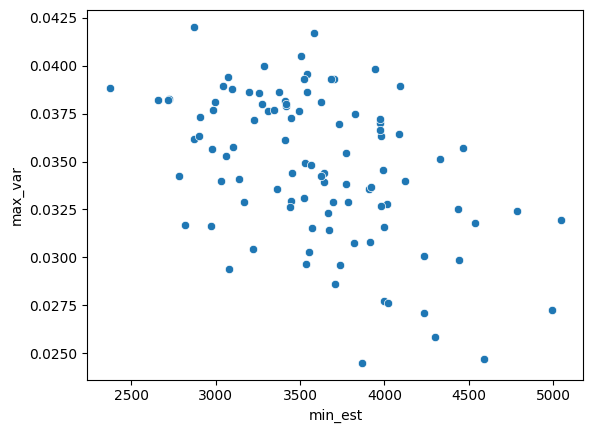

In [64]:
sns.scatterplot(x='min_est', y='max_var', data=A)

In [65]:
# get the two variables for Dcbc and log_det
log_det_list = A['log_det_5'].values
dcbc_list = A['dcbc'].values

from scipy.stats import pearsonr
r_value, p_value = pearsonr(log_det_list, dcbc_list)

print(f"Correlation between log_det and DCBC: {r_value}, p-value: {p_value}")

Correlation between log_det and DCBC: 0.14017197816750457, p-value: 0.1642331731000433


In [66]:
# get the two variables for DCBC and min_est
min_est_list = A['min_est'].values
dcbc_list = A['dcbc'].values

r_value, p_value = pearsonr(min_est_list, dcbc_list)

print(f"Correlation between min_est and DCBC: {r_value}, p-value: {p_value}")


Correlation between min_est and DCBC: -0.08394600903470388, p-value: 0.40632790402956454


In [67]:
# get the two variables for DCBC and max_var
max_var_list = A['max_var'].values
dcbc_list = A['dcbc'].values

r_value, p_value = pearsonr(max_var_list, dcbc_list)

print(f"Correlation between max_var and DCBC: {r_value}, p-value: {p_value}")

Correlation between max_var and DCBC: 0.15187632883356764, p-value: 0.1314435581865938


In [71]:
# get the two variables for DCBC and max_var
max_var_list = A['off_diag'].values
dcbc_list = A['dcbc'].values

r_value, p_value = pearsonr(max_var_list, dcbc_list)

print(f"Correlation between max_var and DCBC: {r_value}, p-value: {p_value}")

Correlation between max_var and DCBC: 0.026198755233876207, p-value: 0.7958373009629672


In [ ]:
# get the two variables for DCBC and max_var
max_var_list = A['max_var'].values
dcbc_list = A['dcbc'].values

r_value, p_value = pearsonr(max_var_list, dcbc_list)

print(f"Correlation between max_var and DCBC: {r_value}, p-value: {p_value}")

In [ ]:
# get the two variables for DCBC and max_var
max_var_list = A['composite_90var'].values
dcbc_list = A['dcbc'].values

r_value, p_value = pearsonr(max_var_list, dcbc_list)

print(f"Correlation between max_var and DCBC: {r_value}, p-value: {p_value}")

In [ ]:
# get the two variables for DCBC and max_var
max_var_list = A['composite_75var'].values
dcbc_list = A['dcbc'].values

r_value, p_value = pearsonr(max_var_list, dcbc_list)

print(f"Correlation between max_var and DCBC: {r_value}, p-value: {p_value}")

In [ ]:
# get the two variables for DCBC and max_var
max_var_list = A['composite_50var'].values
dcbc_list = A['dcbc'].values

r_value, p_value = pearsonr(max_var_list, dcbc_list)

print(f"Correlation between max_var and DCBC: {r_value}, p-value: {p_value}")

In [ ]:
# get the two variables for DCBC and max_var
max_var_list = A['composite_10var'].values
dcbc_list = A['dcbc'].values

r_value, p_value = pearsonr(max_var_list, dcbc_list)

print(f"Correlation between max_var and DCBC: {r_value}, p-value: {p_value}")

In [ ]:
# get the two variables for DCBC and max_var
max_var_list = A['off_diag'].values
dcbc_list = A['dcbc'].values

r_value, p_value = pearsonr(max_var_list, dcbc_list)

print(f"Correlation between max_var and DCBC: {r_value}, p-value: {p_value}")